In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [224]:
df = pd.read_parquet("dataset.parquet")

print(df.shape)

(564, 334)


Find all time-series columns

In [225]:
signal_cols = []

for col in df.columns:
    
    first_value = df[col].iloc[0]
    
    if isinstance(first_value, (list, np.ndarray)):
        signal_cols.append(col)

print("Number of time-series columns:", len(signal_cols))

signal_cols[:20]

Number of time-series columns: 136


['DOS_acBatchCounter',
 'DOS_acComp1DosRate',
 'DOS_acComp1Percent',
 'DOS_acComp1TotalWeight',
 'DOS_acComp2DosRate',
 'DOS_acComp2Percent',
 'DOS_acComp2TotalWeight',
 'DOS_acComp3DosRate',
 'DOS_acComp3Percent',
 'DOS_acComp3TotalWeight',
 'DOS_acComp4DosRate',
 'DOS_acComp4Percent',
 'DOS_acComp4TotalWeight',
 'DOS_acDessicantBedCycleTime',
 'DOS_acDryCircuitDewPoint',
 'DOS_acRegCircuitInletTemp',
 'DOS_acTotalWeight',
 'DOS_acWeight',
 'DOS_sfDryerOn',
 'DOS_sfTimerOn']

Count Signals by Prefix

In [226]:
from collections import Counter

prefixes = [col.split("_")[0] for col in signal_cols]

Counter(prefixes)

Counter({'DXP': 69, 'DRY': 24, 'DOS': 21, 'TCE': 11, 'TCN': 11})

List Signals in Each Group

In [227]:
groups = {}

for col in signal_cols:
    prefix = col.split("_")[0]

    if prefix not in groups:
        groups[prefix] = []

    groups[prefix].append(col)

for group, cols in groups.items():

    print(f"\n{group}")
    print("-"*50)

    for c in cols:
        print(c)


DOS
--------------------------------------------------
DOS_acBatchCounter
DOS_acComp1DosRate
DOS_acComp1Percent
DOS_acComp1TotalWeight
DOS_acComp2DosRate
DOS_acComp2Percent
DOS_acComp2TotalWeight
DOS_acComp3DosRate
DOS_acComp3Percent
DOS_acComp3TotalWeight
DOS_acComp4DosRate
DOS_acComp4Percent
DOS_acComp4TotalWeight
DOS_acDessicantBedCycleTime
DOS_acDryCircuitDewPoint
DOS_acRegCircuitInletTemp
DOS_acTotalWeight
DOS_acWeight
DOS_sfDryerOn
DOS_sfTimerOn
DOS_svBatchWeight

DRY
--------------------------------------------------
DRY_HT101_acAirFlow
DRY_HT101_acDryingTime
DRY_HT101_acSensorMoisture
DRY_HT101_acTempDryair
DRY_HT101_acTempReturnAir
DRY_HT101_sfBinOn
DRY_HT101_sfDryingFinished
DRY_HT101_sfTimerOn
DRY_HT101_svDryingTime
DRY_HT101_svTempDryair
DRY_HT101_svTempReturnAir
DRY_HT101_svTempStandby
DRY_HT102_acAirFlow
DRY_HT102_acDryingTime
DRY_HT102_acSensorMoisture
DRY_HT102_acTempDryair
DRY_HT102_acTempReturnAir
DRY_HT102_sfBinOn
DRY_HT102_sfDryingFinished
DRY_HT102_sfTimerOn
DRY_H

Check Signal Lengths

In [228]:
signal_lengths = {}

for col in signal_cols:
    signal_lengths[col] = len(df[col].iloc[0])

length_df = pd.DataFrame(
    signal_lengths.items(),
    columns=["Signal", "Length"]
)

length_df.sort_values("Length")

,Signal,Length
0,DOS_acBatchCounter,27
1,DOS_acComp1DosRate,27
2,DOS_acComp1Percent,27
3,DOS_acComp1TotalWeight,27
4,DOS_acComp2DosRate,27
...,...,...
99,DXP_T_Inj1BrlHtgBit1,11396
100,DXP_TrigClpCfb,11396
101,DXP_TrigClpCfr,11396
102,DXP_TrigClpCls,11396


In [229]:
length_df["Length"].describe()

count      136.000000
mean      5799.948529
std       5699.963474
min         27.000000
25%         27.000000
50%      11396.000000
75%      11396.000000
max      11396.000000
Name: Length, dtype: float64

In [230]:
length_df.groupby("Length").size()

Length
27       45
57       22
11396    69
dtype: int64

In [231]:
length_df["Length"].value_counts().sort_index()

Length
27       45
57       22
11396    69
Name: count, dtype: int64

In [232]:
for group in groups:
    
    sample_signal = groups[group][0]
    
    print(
        f"{group}: {len(df[sample_signal].iloc[0])}"
    )

DOS: 27
DRY: 27
DXP: 11396
TCE: 57
TCN: 57


## Signal Length Analysis

The dataset contains 136 time-series signals belonging to five subsystems.

| Subsystem | Number of Signals | Sequence Length |
|------------|------------------|----------------|
| DOS | 21 | 27 |
| DRY | 24 | 27 |
| TCE | 11 | 57 |
| TCN | 11 | 57 |
| DXP | 69 | 11396 |

The DXP signals contain high-resolution machine cycle data and are significantly longer than the remaining subsystem measurements.

Section 2: Signal Visualization

In [233]:
important_signals = [
    "DXP_Inj1PrsAct",
    "DXP_Inj1VelAct",
    "DXP_Inj1PosAct",
    "DXP_MldCavPrs1Act",
    "TCE_ActualFlowRate",
    "TCN_TemperatureMainLine",
    "DOS_acDryCircuitDewPoint",
    "DRY_HT101_acSensorMoisture"
]

for s in important_signals:
    print(s, s in df.columns)

DXP_Inj1PrsAct True
DXP_Inj1VelAct True
DXP_Inj1PosAct True
DXP_MldCavPrs1Act True
TCE_ActualFlowRate True
TCN_TemperatureMainLine True
DOS_acDryCircuitDewPoint True
DRY_HT101_acSensorMoisture True


Plot Injection Pressure:

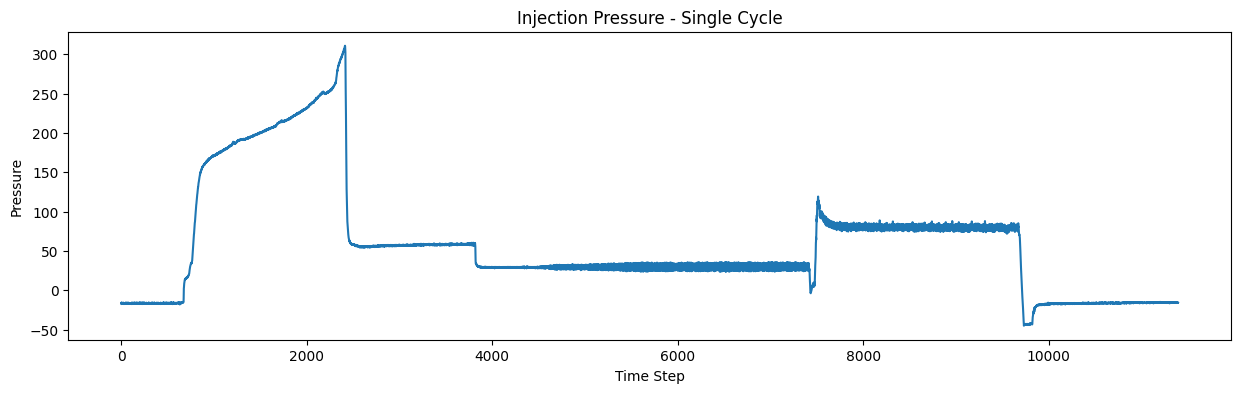

In [234]:
signal_name = "DXP_Inj1PrsAct"

plt.figure(figsize=(15,4))

plt.plot(df[signal_name].iloc[0])

plt.title("Injection Pressure - Single Cycle")
plt.xlabel("Time Step")
plt.ylabel("Pressure")

plt.show()

### Injection Pressure Analysis

The injection pressure signal shows several distinct phases of the molding cycle.

Key observations:

- Rapid pressure increase during injection.
- Maximum pressure reaches approximately 310 units.
- Holding pressure phase is visible after the peak.
- Cooling and mold opening stages appear later in the cycle.
- The signal exhibits strong temporal dynamics, indicating that pressure-related features may be useful for defect prediction.

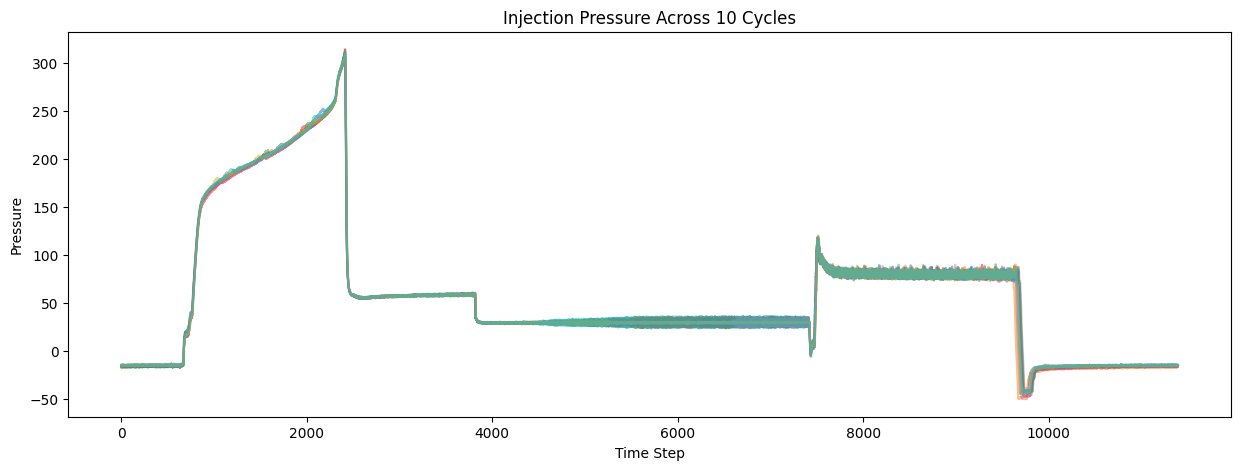

In [235]:
signal_name = "DXP_Inj1PrsAct"

plt.figure(figsize=(15,5))

for i in range(10):
    plt.plot(df[signal_name].iloc[i], alpha=0.5)

plt.title("Injection Pressure Across 10 Cycles")
plt.xlabel("Time Step")
plt.ylabel("Pressure")

plt.show()

### Multi-Cycle Injection Pressure Analysis

The injection pressure signal was visualized across ten production cycles.

Observations:

- The curves overlap almost perfectly.
- The process appears highly stable and repeatable.
- Similar phase transitions are observed in all cycles.
- Only minor variations occur around peak pressure and holding pressure regions.

This indicates that the machine operates under consistent process conditions and that small deviations may be useful indicators for defect prediction.

OK vs NOK Comparison

In [236]:
df["LBL_NOK"].value_counts()

LBL_NOK
0    409
1    155
Name: count, dtype: int64

### Quality Label Distribution

The dataset contains 564 production cycles.

- OK parts: 409 (72.5%)
- NOK parts: 155 (27.5%)

Although the classes are imbalanced, both classes contain sufficient samples for meaningful comparison and model training.

Create the OK vs NOK Plot

Minimum signal length: 8041


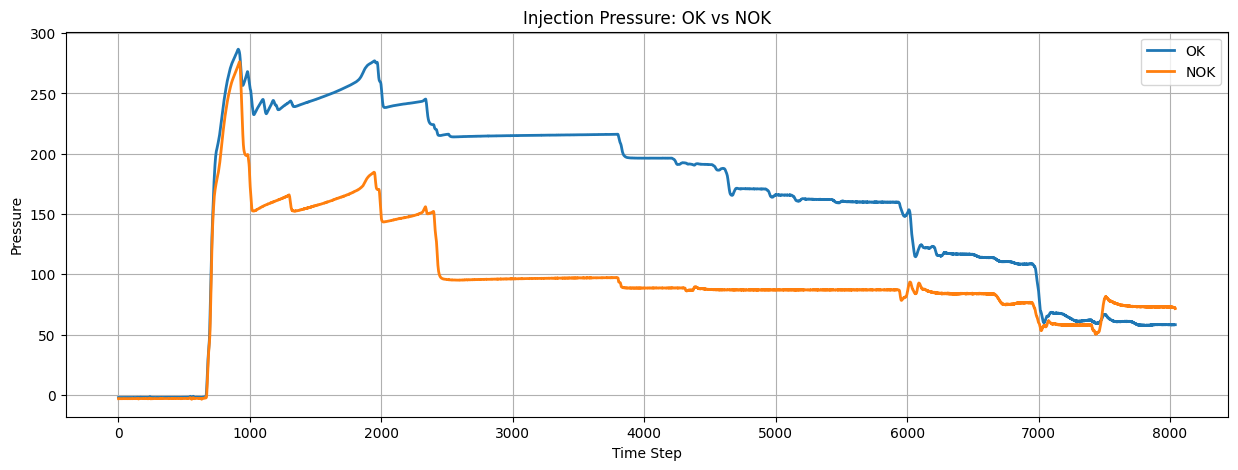

In [237]:
signal_name = "DXP_Inj1PrsAct"

ok = df[df["LBL_NOK"] == 0]
nok = df[df["LBL_NOK"] == 1]

# Find minimum signal length
min_len = min(
    df[signal_name].apply(len)
)

print("Minimum signal length:", min_len)

# Trim all signals to same length
ok_array = np.array([
    np.array(x[:min_len], dtype=float)
    for x in ok[signal_name]
])

nok_array = np.array([
    np.array(x[:min_len], dtype=float)
    for x in nok[signal_name]
])

# Calculate mean curves
ok_mean = ok_array.mean(axis=0)
nok_mean = nok_array.mean(axis=0)

plt.figure(figsize=(15,5))

plt.plot(ok_mean, label="OK", linewidth=2)
plt.plot(nok_mean, label="NOK", linewidth=2)

plt.title("Injection Pressure: OK vs NOK")
plt.xlabel("Time Step")
plt.ylabel("Pressure")

plt.legend()
plt.grid(True)
plt.show()

### Injection Pressure: OK vs NOK

The average injection pressure curves for OK and NOK parts show substantial differences throughout the molding cycle.

Observations:
- OK parts exhibit higher peak injection pressure.
- The holding pressure phase is significantly higher for OK parts.
- NOK parts maintain lower pressure levels across most cycle stages.
- The separation between the two curves indicates that injection pressure contains strong information related to product quality.

These findings suggest that pressure-related features may be highly relevant for defect prediction models.

In [238]:
df["DXP_Inj1PrsAct"].apply(len).describe()

count      564.000000
mean     10989.260638
std        993.819473
min       8041.000000
25%      11313.000000
50%      11387.000000
75%      11527.000000
max      12079.000000
Name: DXP_Inj1PrsAct, dtype: float64

In [239]:
df["DXP_Inj1PrsAct"].apply(len).value_counts().head(20)

DXP_Inj1PrsAct
11531    16
11529    13
11527    12
11331    10
11530    10
11327    10
11328     9
11392     9
11325     9
11528     9
11552     8
11525     8
11330     7
11332     7
11329     7
11396     7
11532     7
11549     6
11526     6
11546     6
Name: count, dtype: int64

In [240]:
lengths = df["DXP_Inj1PrsAct"].apply(len)

print("Less than 10000 samples:")
print((lengths < 10000).sum())

print("\nPercentage:")
print(round((lengths < 10000).mean()*100,2), "%")

Less than 10000 samples:
72

Percentage:
12.77 %


same analysis for these three signals:

In [241]:
signals_to_compare = [
    "DXP_Inj1VelAct",
    "DXP_Inj1PosAct",
    "DXP_MldCavPrs1Act"
]

Create a reusable function:

In [242]:
def compare_ok_nok(signal_name):

    ok = df[df["LBL_NOK"] == 0]
    nok = df[df["LBL_NOK"] == 1]

    min_len = min(df[signal_name].apply(len))

    ok_array = np.array([
        np.array(x[:min_len], dtype=float)
        for x in ok[signal_name]
    ])

    nok_array = np.array([
        np.array(x[:min_len], dtype=float)
        for x in nok[signal_name]
    ])

    ok_mean = ok_array.mean(axis=0)
    nok_mean = nok_array.mean(axis=0)

    plt.figure(figsize=(14,5))

    plt.plot(ok_mean, label="OK")
    plt.plot(nok_mean, label="NOK")

    plt.title(signal_name)
    plt.xlabel("Time Step")
    plt.ylabel("Value")

    plt.legend()
    plt.grid(True)

    plt.show()

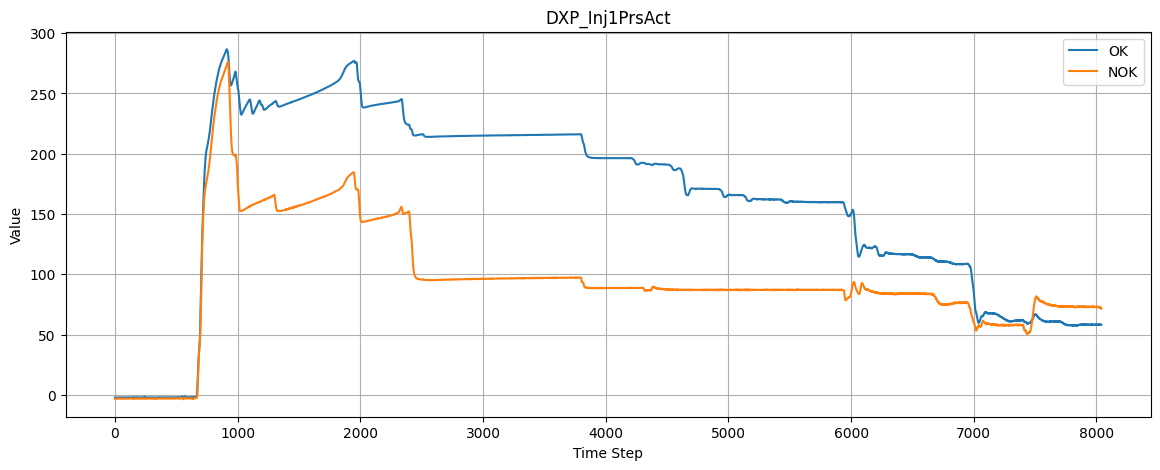

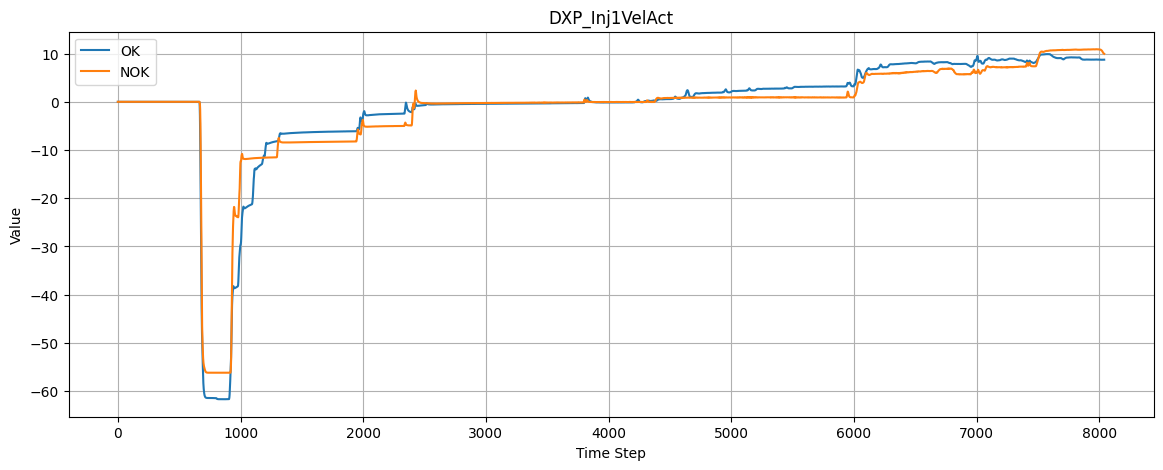

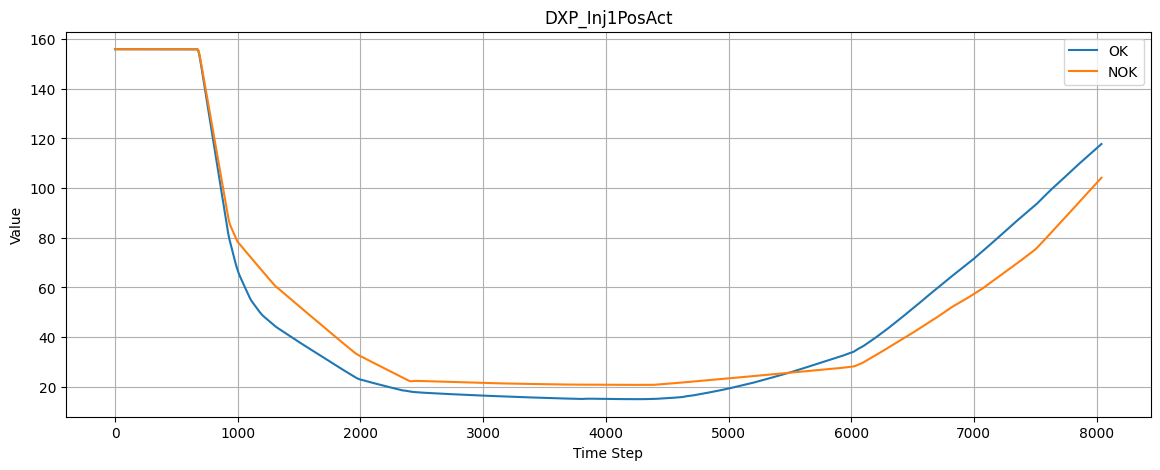

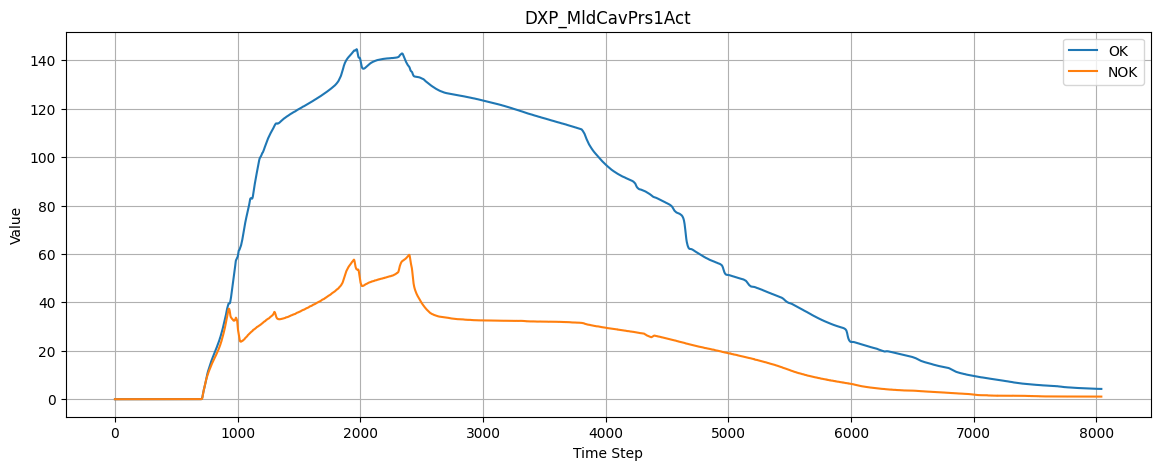

In [243]:
for signal in [
    "DXP_Inj1PrsAct",
    "DXP_Inj1VelAct",
    "DXP_Inj1PosAct",
    "DXP_MldCavPrs1Act"
]:
    compare_ok_nok(signal)

### Key Findings from OK vs NOK Analysis

* **DXP_Inj1PrsAct (Injection Pressure):** Strong separation between OK and NOK cycles, indicating high predictive potential.
* **DXP_MldCavPrs1Act (Mold Cavity Pressure):** Significant differences observed throughout the cycle, making it a highly informative signal.
* **DXP_Inj1PosAct (Injection Position):** Noticeable divergence between OK and NOK parts, especially in later stages of the cycle.
* **DXP_Inj1VelAct (Injection Velocity):** Moderate differences observed; less discriminative than pressure-related signals.

| Signal            | Separation | Importance |
| ----------------- | ---------- | ---------- |
| DXP_Inj1PrsAct    | Very High  | ⭐⭐⭐⭐⭐      |
| DXP_MldCavPrs1Act | Very High  | ⭐⭐⭐⭐⭐      |
| DXP_Inj1PosAct    | High       | ⭐⭐⭐⭐       |
| DXP_Inj1VelAct    | Moderate   | ⭐⭐⭐        |


Check Defect Counts

In [244]:
label_cols = [
    c for c in df.columns
    if c.startswith("LBL_")
    and c != "LBL_NOK"
]

for label in label_cols:
    print(label)
    print(df[label].value_counts())
    print("-"*40)

LBL_OldGranulate
LBL_OldGranulate
0.0    403
1.0      9
Name: count, dtype: int64
----------------------------------------
LBL_SinkMarks
LBL_SinkMarks
0    421
1    143
Name: count, dtype: int64
----------------------------------------
LBL_SprueCircle
LBL_SprueCircle
0    492
1     72
Name: count, dtype: int64
----------------------------------------
LBL_StreaksLevel1
LBL_StreaksLevel1
0    534
1     30
Name: count, dtype: int64
----------------------------------------
LBL_StreaksLevel2
LBL_StreaksLevel2
0    546
1     18
Name: count, dtype: int64
----------------------------------------
LBL_StreaksLevel3
LBL_StreaksLevel3
0    516
1     48
Name: count, dtype: int64
----------------------------------------
LBL_Underfilled
LBL_Underfilled
0    504
1     60
Name: count, dtype: int64
----------------------------------------


### Defect Distribution

The dataset contains multiple defect categories with varying frequencies.

| Defect Type     | Defective Samples |
| --------------- | ----------------- |
| Sink Marks      | 143               |
| Sprue Circle    | 72                |
| Streaks Level 2 | 60                |
| Streaks Level 1 | 30                |
| Old Granulate   | 9                 |

For further analysis, Sink Marks, Sprue Circle, and Streaks Level 2 were selected due to their relatively larger number of defective samples.


Create a reusable function:

In [245]:
def compare_defect(signal_name, label):

    good = df[df[label] == 0]
    bad = df[df[label] == 1]

    min_len = min(df[signal_name].apply(len))

    good_array = np.array([
        np.array(x[:min_len], dtype=float)
        for x in good[signal_name]
    ])

    bad_array = np.array([
        np.array(x[:min_len], dtype=float)
        for x in bad[signal_name]
    ])

    plt.figure(figsize=(14,5))

    plt.plot(
        good_array.mean(axis=0),
        label="No Defect"
    )

    plt.plot(
        bad_array.mean(axis=0),
        label="Defect"
    )

    plt.title(f"{signal_name} vs {label}")

    plt.legend()
    plt.grid(True)

    plt.show()

Sink Marks

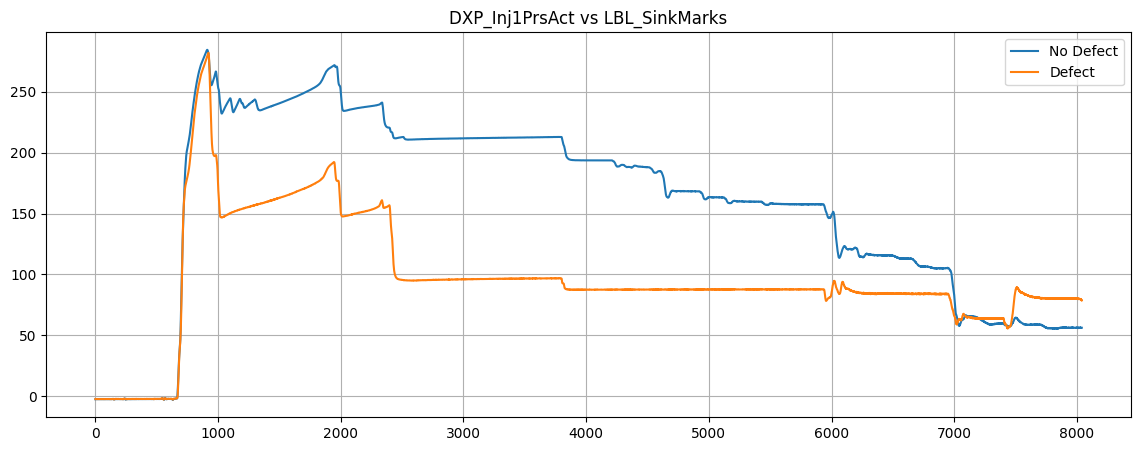

In [246]:
compare_defect(
    "DXP_Inj1PrsAct",
    "LBL_SinkMarks"
)

### Sink Marks Analysis

The injection pressure signal shows a clear separation between parts with and without sink marks.

**Observations:**

* Parts without sink marks exhibit significantly higher pressure throughout the cycle.
* Sink mark defects are associated with lower peak and holding pressures.
* The difference remains consistent across most process phases.

**Conclusion:**
Injection pressure appears to be strongly related to the occurrence of sink marks and is a promising feature for defect prediction.


Sprue Circle

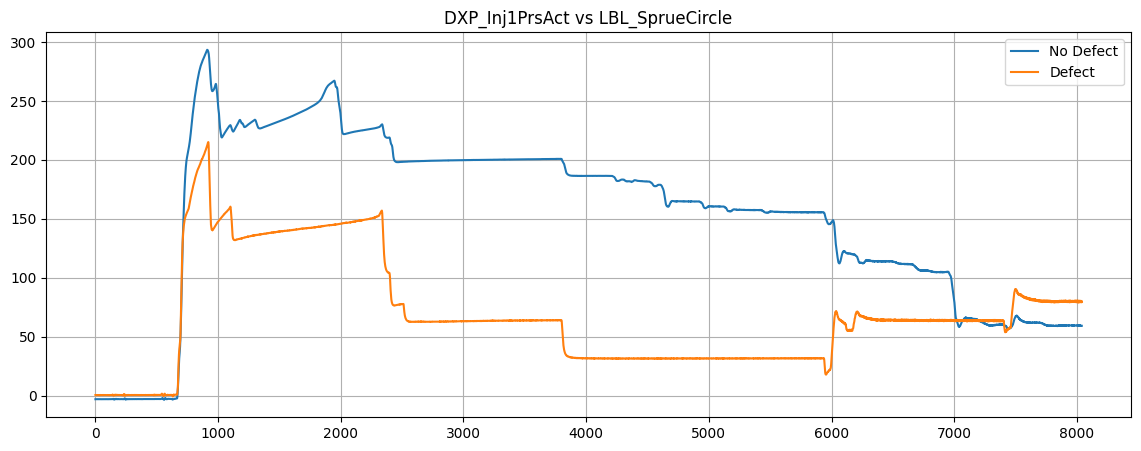

In [247]:
compare_defect(
    "DXP_Inj1PrsAct",
    "LBL_SprueCircle"
)

### Sprue Circle Analysis

The injection pressure signal shows clear differences between parts with and without sprue circle defects.

**Observations:**

* Defective parts exhibit lower pressure levels during injection and holding phases.
* Peak pressure is noticeably lower for defective parts.
* The separation remains visible throughout most of the molding cycle.

**Conclusion:**
Injection pressure is strongly associated with sprue circle defects and provides useful information for defect classification.


Streaks Level 2

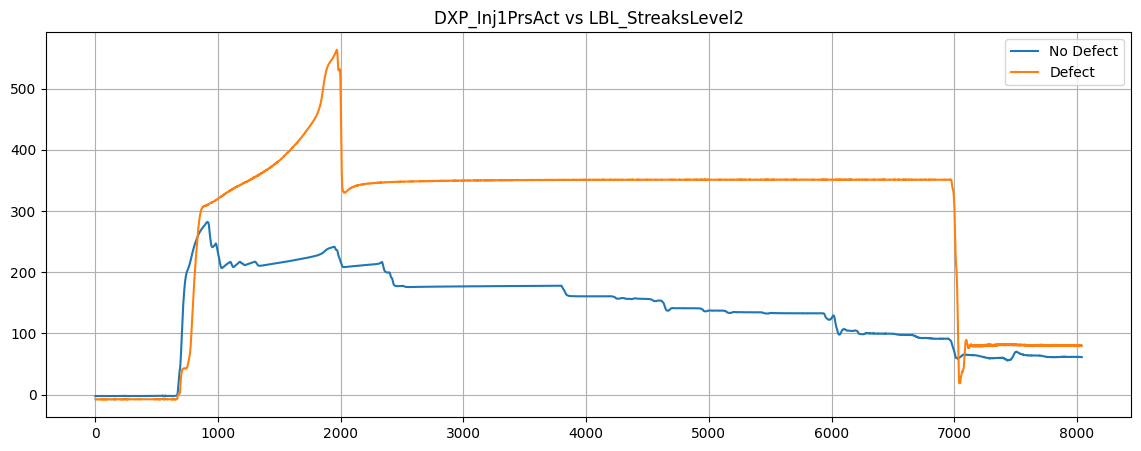

In [248]:
compare_defect(
    "DXP_Inj1PrsAct",
    "LBL_StreaksLevel2"
)

### Streaks Level 2 Analysis

The injection pressure signal shows a strong separation between defective and non-defective parts.

**Observations:**

* Defective parts exhibit significantly higher pressure levels throughout the cycle.
* Peak pressure is substantially higher for defective parts.
* The difference remains consistent during both injection and holding phases.

**Conclusion:**
Injection pressure appears to be strongly associated with Streaks Level 2 defects, indicating that excessive pressure may contribute to defect formation.


# 10. Feature Extraction

In [249]:
from scipy.stats import skew, kurtosis
import numpy as np
import pandas as pd

Feature Extraction Function

In [250]:
def extract_features(signal):

    signal = np.array(signal, dtype=float)

    if np.isnan(signal).all():
        return None

    if np.nanstd(signal) == 0:
        skew_value = 0
        kurtosis_value = 0
    else:
        skew_value = skew(signal, nan_policy="omit")
        kurtosis_value = kurtosis(signal, nan_policy="omit")

    return {
        "mean": np.nanmean(signal),
        "std": np.nanstd(signal),
        "min": np.nanmin(signal),
        "max": np.nanmax(signal),
        "range": np.nanmax(signal) - np.nanmin(signal),
        "median": np.nanmedian(signal),
        "skew": skew_value,
        "kurtosis": kurtosis_value,
        "energy": np.nansum(signal**2),
        "rms": np.sqrt(np.nanmean(signal**2)),
        "peak": np.nanmax(np.abs(signal))
    }

Test on One Signal

In [251]:
signal = df["DXP_Inj1PrsAct"].iloc[0]

extract_features(signal)

{'mean': np.float64(58.96998239466289),
 'std': np.float64(71.32557034402099),
 'min': np.float64(-44.91600036621094),
 'max': np.float64(310.79998779296875),
 'range': np.float64(355.7159881591797),
 'median': np.float64(33.917999267578125),
 'skew': np.float64(1.3319437895893356),
 'kurtosis': np.float64(1.3044226806667565),
 'energy': np.float64(97604413.03397071),
 'rms': np.float64(92.54618203106348),
 'peak': np.float64(310.79998779296875)}

### Example Feature Extraction

For the signal `DXP_Inj1PrsAct`, statistical features were extracted to summarize its temporal behavior.

- Mean pressure: 58.97
- Maximum pressure: 310.80
- Standard deviation: 71.33
- RMS value: 92.55
- Positive skewness indicates a longer right tail due to pressure peaks.

These features transform variable-length time-series signals into fixed-length numerical representations suitable for machine learning models.

Some signals were nearly constant across time. For such signals, skewness and kurtosis were set to 0 to avoid unstable statistical calculations.

Find invalid signals

In [252]:
invalid_signals = []

for signal in signal_cols:

    first_signal = np.array(df[signal].iloc[0], dtype=float)

    if np.isnan(first_signal).all():
        invalid_signals.append(signal)

print("Invalid signals:", len(invalid_signals))
print(invalid_signals)

Invalid signals: 8
['DOS_sfDryerOn', 'DOS_sfTimerOn', 'DRY_HT101_sfBinOn', 'DRY_HT101_sfDryingFinished', 'DRY_HT101_sfTimerOn', 'DRY_HT102_sfBinOn', 'DRY_HT102_sfDryingFinished', 'DRY_HT102_sfTimerOn']


### Invalid Signal Removal

During preprocessing, eight signals were found to contain only missing values across all production cycles.

These signals were removed before feature extraction because they do not provide any useful information for analysis or model training.

Removed signals:
- DOS_sfDryerOn
- DOS_sfTimerOn
- DRY_HT101_sfBinOn
- DRY_HT101_sfDryingFinished
- DRY_HT101_sfTimerOn
- DRY_HT102_sfBinOn
- DRY_HT102_sfDryingFinished
- DRY_HT102_sfTimerOn

Clean Signal List

In [253]:
signal_cols_clean = [
    s for s in signal_cols
    if s not in invalid_signals
]

print("Original signals:", len(signal_cols))
print("Valid signals:", len(signal_cols_clean))

Original signals: 136
Valid signals: 128


In [254]:
# feature_rows = []

# for idx, row in df.iterrows():

#     sample_features = {}

#     for signal in signal_cols:

#         feats = extract_features(row[signal])

#         for feature_name, value in feats.items():

#             sample_features[
#                 f"{signal}_{feature_name}"
#             ] = value

#     feature_rows.append(sample_features)

# feature_df = pd.DataFrame(feature_rows)

feature_rows = []

for idx, row in df.iterrows():

    sample_features = {}

    for signal in signal_cols_clean:

        feats = extract_features(row[signal])

        # Skip signal if it returned None
        if feats is None:
            continue

        for feature_name, value in feats.items():
            sample_features[f"{signal}_{feature_name}"] = value

    feature_rows.append(sample_features)

feature_df = pd.DataFrame(feature_rows)

print(feature_df.shape)

C:\Users\ckary\AppData\Local\Temp\ipykernel_4532\941161540.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew_value = skew(signal, nan_policy="omit")
C:\Users\ckary\AppData\Local\Temp\ipykernel_4532\941161540.py:13: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis_value = kurtosis(signal, nan_policy="omit")


(564, 1408)


In [255]:
feature_df = feature_df.fillna(0)

print(feature_df.shape)
print("Missing values:", feature_df.isnull().sum().sum())

(564, 1408)
Missing values: 0


In [256]:
label_cols = [col for col in df.columns if col.startswith("LBL_")]

final_dataset = pd.concat(
    [feature_df, df[label_cols]],
    axis=1
)

print(final_dataset.shape)

(564, 1416)


In [257]:
final_dataset.to_csv("timeseries_features.csv", index=False)

print("timeseries_features.csv saved successfully")

timeseries_features.csv saved successfully


## Feature Extraction Summary

After removing 8 invalid signals containing only missing values, statistical features were extracted from 128 valid time-series signals.

A total of 1,408 engineered features were generated and combined with defect labels, resulting in a final dataset of 564 samples and 1,416 columns.

The dataset was exported as `timeseries_features.csv` for machine learning model development.